# 08 — Wiki Training Pairs

The wiki covers deployed usage patterns, real-world decisions, and edge cases that
don't appear in the formal book — things developers actually search for when they're
stuck. Mining it adds practical diversity to the training set.

For each wiki page, sections are split to fit the model's context window. The model
generates 5 targeted Q&A pairs per section, mixing question types: concept, syntax,
how-to, comparison, and code completion. This variety ensures the model can handle
any shape of developer question.

The generation prompt asks for JSON output for reliable parsing. A retry loop with
increasing temperature recovers from occasional JSON parse failures.

**Wiki source:** cloned from `git@git.ausdertechnik.de:arolang/aro.wiki.git`
(re-cloned automatically if the local copy is absent or stale)

**Input:**  `../data/wiki/` (markdown files, cloned from GitLab)
**Output:** `../data/02_knowledge/knowledge_pairs.jsonl`
            merged into `../data/02_knowledge/knowledge_pairs.jsonl`

## Setup & clone wiki

In [1]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import json, re, sys, subprocess, hashlib
from pathlib import Path
from collections import defaultdict

DATA_OUT  = GLOBAL_OUT_DIR / '../data/07b_wiki'
OWN_FILE  = DATA_OUT / 'wiki_pairs.jsonl'

DATA_OUT.mkdir(parents=True, exist_ok=True)
WIKI_DIR.mkdir(parents=True, exist_ok=True)

def clone_or_update_wiki():
    git_dir = WIKI_DIR / '.git'
    if git_dir.exists():
        result = subprocess.run(
            ['git', '-C', str(WIKI_DIR), 'pull', '--ff-only'],
            capture_output=True, text=True
        )
        print(f'Wiki updated: {result.stdout.strip() or result.stderr.strip()}')
    else:
        subprocess.run(
            ['git', 'clone', GITLAB_WIKI, str(WIKI_DIR)],
            check=True
        )
        # GitLab wiki uses 'master' branch
        subprocess.run(['git', '-C', str(WIKI_DIR), 'checkout', 'master'],
                       capture_output=True)
        print(f'Wiki cloned to {WIKI_DIR}')

clone_or_update_wiki()

pages = sorted(WIKI_DIR.glob('*.md'))
# Skip sidebar — it's navigation only
pages = [p for p in pages if p.name != '_Sidebar.md']
print(f'Wiki pages: {len(pages)}')
for p in pages:
    print(f'  {p.name}')


def _show_sample(pairs, n=2, label=''):
    import random as _r
    sample_pool = _r.sample(pairs, min(n, len(pairs)))
    print(f'\n── Sample ({label}, {len(pairs)} total) ──────────────────────')
    for i, s in enumerate(sample_pool, 1):
        if 'messages' in s:
            user = s['messages'][1]['content'] if len(s['messages']) > 1 else ''
            asst = s['messages'][2]['content'] if len(s['messages']) > 2 else ''
        else:
            user = s.get('instruction', s.get('user', ''))
            asst = s.get('output', s.get('assistant', ''))
        task = s.get('task_type', s.get('source', '?'))
        print(f'  [{i}] task={task}')
        print(f'       USER: {user[:120].strip()!r}')
        print(f'       ASST: {asst[:120].strip()!r}')
    print('─' * 60)

Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO-App
Pairs:     /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Volumes/Models/data/../data/adapters


Cloning into '/Volumes/Models/data/../data/wiki'...


Wiki cloned to /Volumes/Models/data/../data/wiki
Wiki pages: 34
  Action-Developer-Guide.md
  Getting-Started.md
  Guide-Actions.md
  Guide-Application-Lifecycle.md
  Guide-Computations.md
  Guide-Concurrency.md
  Guide-Context-Aware-Responses.md
  Guide-Control-Flow.md
  Guide-Data-Pipelines.md
  Guide-Dates.md
  Guide-Error-Handling.md
  Guide-Events.md
  Guide-Feature-Sets.md
  Guide-File-System.md
  Guide-HTTP-Client.md
  Guide-HTTP-Services.md
  Guide-Package-Manager.md
  Guide-Repositories.md
  Guide-Services.md
  Guide-Sockets.md
  Guide-Streaming-Execution.md
  Guide-System-Commands.md
  Guide-The-Basics.md
  Guide-Type-System.md
  Guide-Variables.md
  Guide-WebSockets.md
  Home.md
  Installation.md
  Language-Tour.md
  Reference-Actions.md
  Reference-Grammar.md
  Reference-Statements.md
  Reference-System-Objects.md
  Start-With-ARO.md


## Section splitter

Split each page into sections so each chunk fits in the model's context window.

In [2]:
MAX_SECTION_CHARS = 3000   # ~750 tokens — leaves room for prompt + response

def split_into_sections(path):
    """
    Returns list of dicts: { page, heading, content, section_id }
    Merges short consecutive sections so we don't generate pairs for 3-line stubs.
    """
    text     = Path(path).read_text()
    page     = Path(path).stem
    heading_re = re.compile(r'^(#{1,3} .+)', re.MULTILINE)

    parts = heading_re.split(text)
    # parts[0] = content before first heading (page intro)
    # parts[1,2] = heading, body; parts[3,4] = heading, body; ...

    sections = []

    # Include the page intro if substantial
    intro = parts[0].strip()
    if len(intro) > 100:
        sections.append({
            'page':    page,
            'heading': page.replace('-', ' '),
            'content': intro[:MAX_SECTION_CHARS],
        })

    i = 1
    pending_heading = ''
    pending_content = ''

    while i < len(parts):
        heading = re.sub(r'^#+\s*', '', parts[i]).strip()
        body    = parts[i + 1].strip() if i + 1 < len(parts) else ''
        i += 2

        # Accumulate short sections together
        combined = (pending_content + '\n\n' + body).strip()
        if len(combined) < 200 and i < len(parts):
            pending_heading = pending_heading or heading
            pending_content = combined
            continue

        # Flush
        if pending_content:
            sections.append({
                'page':    page,
                'heading': pending_heading,
                'content': (pending_content + '\n\n' + body).strip()[:MAX_SECTION_CHARS],
            })
            pending_heading = ''
            pending_content = ''
        elif len(body) >= 100:
            sections.append({
                'page':    page,
                'heading': heading,
                'content': body[:MAX_SECTION_CHARS],
            })

    if pending_content:
        sections.append({
            'page':    page,
            'heading': pending_heading,
            'content': pending_content[:MAX_SECTION_CHARS],
        })

    # Add a stable section_id for resume tracking
    for s in sections:
        raw = f"{s['page']}::{s['heading']}"
        s['section_id'] = hashlib.md5(raw.encode()).hexdigest()[:12]

    return sections


# Preview
all_sections = []
for page in pages:
    secs = split_into_sections(page)
    all_sections.extend(secs)

print(f'Total sections across {len(pages)} pages: {len(all_sections)}')
print(f'  Avg section length: {sum(len(s["content"]) for s in all_sections) // len(all_sections)} chars')
print(f'  Estimated pairs:    {len(all_sections) * 5}')

Total sections across 34 pages: 649
  Avg section length: 485 chars
  Estimated pairs:    3245


## Load model

In [3]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

with open(DATA_IN / 'knowledge.json') as f:
    kb = json.load(f)

# Use load_model() which auto-loads the warm-start adapter from knowledge.json
# and returns (model, tokenizer, load_fn, generate_fn, make_sampler_fn)
model, tokenizer, _, mlx_generate, make_sampler = load_model(kb=kb)
print('Model ready.')

Fine-tuned model not found on HuggingFace, using base: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO-App
Pairs:     /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Volumes/Models/data/../data/adapters


/Library/Python/3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kris/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit with warm-start adapter...


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 172368.66it/s]

  Adapter: /Volumes/Models/data/../data/adapters/warm_start
Model ready.
Model ready.


## Pair generation prompt

The model receives a wiki section and returns a JSON array of 5 Q&A pairs.

In [4]:
SYSTEM_PROMPT = """You are generating training data for a language model that learns ARO (Action Result Object), a DSL for expressing business logic as natural-language statements.

ARO SYNTAX REFERENCE:
  (FeatureSetName: BusinessActivity) {
      Verb [the] <result[:qualifier]> preposition [the] <object[:qualifier]>.
  }
- String concatenation: ++ (NOT +)
- Variable names: hyphenated lowercase, immutable (new name per transform)
- Control flow: when <cond> { ... }, For each <x> in <list> { ... }
- Actions: Extract, Retrieve, Compute, Validate, Create, Store, Return, Emit, Log, Send, etc.
- Return statuses: <OK: status>, <Created: status>, <NotFound: status>, <BadRequest: status>
- HTTP: openapi.yaml required; operationId matches feature set name

You will receive a section from the ARO documentation wiki.
Your task: generate exactly 5 instruction/answer pairs that a developer learning ARO would find useful.

Guidelines:
- Mix question types: concept questions, syntax questions, "how do I..." questions, code completion, comparisons
- Answers must be ACCURATE and GROUNDED in the provided documentation — do NOT invent features
- Include ARO code examples in answers wherever the documentation shows them
- Instructions should be natural questions a developer would ask
- Keep answers concise but complete (2-10 sentences + code if applicable)

Output ONLY a valid JSON array — no markdown, no explanation, no preamble:
[
  {"instruction": "...", "answer": "..."},
  {"instruction": "...", "answer": "..."},
  {"instruction": "...", "answer": "..."},
  {"instruction": "...", "answer": "..."},
  {"instruction": "...", "answer": "..."}
]"""

QUESTION_TYPES = [
    'concept',      # What is X? What does X mean?
    'syntax',       # How do you write X in ARO?
    'how_to',       # How do I accomplish Y using ARO?
    'comparison',   # What is the difference between X and Y?
    'code',         # Write an ARO feature set that does Z.
]

def make_generation_prompt(section):
    page_name = section['page'].replace('-', ' ')
    heading   = section['heading']
    content   = section['content']

    question_type_hint = ', '.join(QUESTION_TYPES)

    return (
        f"Wiki page: **{page_name}**\n"
        f"Section: **{heading}**\n\n"
        f"{content}\n\n"
        f"---\n"
        f"Generate 5 instruction/answer training pairs covering these question types: "
        f"{question_type_hint}.\n"
        f"Output only the JSON array."
    )

# Preview prompt for one section
sample = all_sections[3]
print(make_generation_prompt(sample)[:600] + '...')

Wiki page: **Action Developer Guide**
Section: **Key Points**

- **Sendable**: Actions must be thread-safe
- **Static properties**: Define metadata at compile time
- **Async/throws**: Actions can be async and may throw errors
- **Returns `any Sendable`**: Results must be sendable across concurrency domains

---

---
Generate 5 instruction/answer training pairs covering these question types: concept, syntax, how_to, comparison, code.
Output only the JSON array....


## Generation + JSON parsing

In [5]:
MAX_TOKENS  = 1800   # was 1400 — Qwen3 thinking eats tokens
MAX_RETRIES = 3      # was 2


def generate_raw(prompt, temp=0.5):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': prompt},
    ]
    # Disable Qwen3 thinking mode — saves 500-1000 tokens per call and
    # prevents <think> blocks from crowding out the actual JSON response.
    try:
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
            enable_thinking=False,
        )
    except TypeError:
        # Fallback for tokenizers that don't support enable_thinking
        text = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )
    tokens = tokenizer.encode(text)
    return mlx_generate(
        model, tokenizer,
        prompt=tokens,
        max_tokens=MAX_TOKENS,
        sampler=make_sampler(temp=temp),
        verbose=False,
    )


def extract_json_array(text):
    """Extract first JSON array from model output.

    Handles:
    - Qwen3 <think>...</think> blocks (strip before searching)
    - Markdown fences
    - Truncated output (repair by closing at last complete object)
    - String-aware bracket matching (don't count [ inside string values)
    """
    # 1. Strip Qwen3 thinking blocks
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL).strip()

    # 2. Strip markdown fences
    text = re.sub(r'^```(?:json)?\s*', '', text.strip(), flags=re.MULTILINE)
    text = re.sub(r'```\s*$', '', text.strip(), flags=re.MULTILINE)
    text = text.strip()

    # 3. Find the start of the outermost array
    start = text.find('[')
    if start == -1:
        return None

    # 4. String-aware bracket matching
    depth       = 0
    in_string   = False
    escape_next = False
    end         = start
    for i, ch in enumerate(text[start:], start):
        if escape_next:
            escape_next = False
            continue
        if ch == '\\' and in_string:
            escape_next = True
            continue
        if ch == '"':
            in_string = not in_string
        if in_string:
            continue
        if ch == '[':
            depth += 1
        elif ch == ']':
            depth -= 1
            if depth == 0:
                end = i + 1
                break

    candidate = text[start:end]

    # 5. Try direct parse
    try:
        return json.loads(candidate)
    except json.JSONDecodeError:
        pass

    # 6. Repair: model truncated output — close at last complete object
    last = max(candidate.rfind('},'), candidate.rfind('}'))
    if last > 0:
        repaired = candidate[:last + 1].rstrip(',').rstrip() + ']'
        try:
            return json.loads(repaired)
        except json.JSONDecodeError:
            pass

    return None


def validate_pair(pair, page):
    """Returns cleaned pair or None. Accepts both 'answer' and 'output' keys."""
    if not isinstance(pair, dict):
        return None
    instr  = str(pair.get('instruction', '')).strip()
    answer = str(pair.get('answer', pair.get('output', ''))).strip()
    if len(instr) < 10 or len(answer) < 15:
        return None
    return {
        'instruction': instr,
        'output':      answer,
        'source':      f'wiki:{page}',
        'score':       1.0,
    }


def make_simple_prompt(section):
    """Shorter fallback prompt — 3 pairs instead of 5, less demanding format."""
    return (
        f"Wiki: **{section['page'].replace('-', ' ')}** — {section['heading']}\n\n"
        f"{section['content']}\n\n"
        f"---\nGenerate 3 instruction/answer training pairs as a JSON array:\n"
        f'[{{"instruction":"...","answer":"..."}}]'
    )


def generate_pairs_for_section(section, _log_raw=False):
    """Returns list of valid pairs (may be empty on parse failure)."""
    prompts = [
        (make_generation_prompt(section), 0.4),
        (make_generation_prompt(section), 0.6),
        (make_simple_prompt(section),     0.5),  # simpler prompt on last retry
        (make_simple_prompt(section),     0.7),
    ]

    for attempt in range(min(MAX_RETRIES + 1, len(prompts))):
        prompt, temp = prompts[attempt]
        raw = generate_raw(prompt, temp=temp)
        arr = extract_json_array(raw)
        if arr and isinstance(arr, list):
            pairs = [validate_pair(p, section['page']) for p in arr]
            pairs = [p for p in pairs if p is not None]
            if pairs:
                return pairs
        if _log_raw and attempt == MAX_RETRIES:
            snippet = raw[:300].replace('\n', '↵')
            tqdm.write(f'    [RAW] {snippet}')

    return []


print('Generation helpers ready (thinking disabled, JSON repair enabled).')


Generation helpers ready (thinking disabled, JSON repair enabled).


## Main generation loop

In [6]:
try:
    import ipywidgets
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

import re as _re
SKIP_PATTERNS = _re.compile(
    r'roadmap|contributing|installation|getting.?started|'
    r'changelog|release.?notes|license|credits|authors',
    _re.IGNORECASE
)

# ── Resume: load already-processed section IDs ───────────────────────────────
all_pairs     = []
done_sections = set()

if OWN_FILE.exists():
    with open(OWN_FILE) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            p = json.loads(line)
            all_pairs.append(p)
            if 'section_id' in p:
                done_sections.add(p['section_id'])
    print(f'Resuming — {len(all_pairs)} pairs already saved, {len(done_sections)} sections done')

remaining = [s for s in all_sections if s['section_id'] not in done_sections]
print(f'Sections to process: {len(remaining)} / {len(all_sections)}')

# ── Per-page stats ────────────────────────────────────────────────────────────
page_stats = defaultdict(lambda: {'sections': 0, 'pairs': 0, 'failed': 0})
total_failed = 0

# Log raw output for the first N failures per run (helps diagnose new issues)
RAW_LOG_BUDGET = 3
raw_logged = 0

outf = open(OWN_FILE, 'a')

try:
    pbar = tqdm(total=len(remaining), desc='Wiki sections', unit='section')

    for section in remaining:
        page            = section['page']
        section_heading = section['heading']

        if SKIP_PATTERNS.search(section_heading):
            pbar.update(1)
            continue

        pbar.set_description(f'{page[:30]}::{section_heading[:20]}')

        should_log = (raw_logged < RAW_LOG_BUDGET)
        pairs = generate_pairs_for_section(section, _log_raw=should_log)

        if pairs:
            for p in pairs:
                p['section_id'] = section['section_id']
                all_pairs.append(p)
                outf.write(json.dumps(p) + '\n')
            outf.flush()
            page_stats[page]['pairs']    += len(pairs)
            page_stats[page]['sections'] += 1
        else:
            page_stats[page]['failed'] += 1
            total_failed += 1
            raw_logged   += 1
            fail_rate = total_failed / (sum(s['sections'] + s['failed'] for s in page_stats.values()) or 1)
            tqdm.write(f'  [WARN] No pairs for {page}::{section_heading}  '
                       f'(fail rate so far: {fail_rate:.0%})')

        pbar.set_postfix({'pairs': len(all_pairs), 'failed': total_failed})
        pbar.update(1)

finally:
    pbar.close()
    outf.close()

# ── Summary ───────────────────────────────────────────────────────────────────
total_done = sum(s['sections'] + s['failed'] for s in page_stats.values())
overall_fail = total_failed / total_done if total_done else 0
print(f'\n=== Results ===')
print(f'Total pairs generated: {len(all_pairs)}')
print(f'Sections processed:    {total_done}  (failed: {total_failed}, {overall_fail:.0%})')
print()
print(f'{"Page":<45} {"Sections":>8} {"Pairs":>6} {"Failed":>7}')
print('-' * 70)
for page, s in sorted(page_stats.items()):
    print(f'{page:<45} {s["sections"]:>8} {s["pairs"]:>6} {s["failed"]:>7}')

_show_sample(all_pairs, label='NB08 wiki')

Resuming — 2109 pairs already saved, 469 sections done
Sections to process: 174 / 649


Wiki sections:   0%|          | 0/174 [00:00<?, ?section/s]

Action-Developer-Guide::ResultDescriptor:   0%|          | 0/174 [00:00<?, ?section/s]

Action-Developer-Guide::ResultDescriptor:   0%|          | 0/174 [00:40<?, ?section/s, pairs=2112, failed=0]

Action-Developer-Guide::ResultDescriptor:   1%|          | 1/174 [00:40<1:55:29, 40.05s/section, pairs=2112, failed=0]

...

Start-With-ARO::Common ARO Actions:  99%|█████████▉| 173/174 [1:32:35<00:47, 47.12s/section, pairs=2642, failed=52]  

Start-With-ARO::Common ARO Actions:  99%|█████████▉| 173/174 [1:33:15<00:47, 47.12s/section, pairs=2645, failed=52]

Start-With-ARO::Common ARO Actions: 100%|██████████| 174/174 [1:33:15<00:00, 44.93s/section, pairs=2645, failed=52]

Start-With-ARO::Common ARO Actions: 100%|██████████| 174/174 [1:33:15<00:00, 32.16s/section, pairs=2645, failed=52]


=== Results ===
Total pairs generated: 2645
Sections processed:    173  (failed: 52, 30%)

Page                                          Sections  Pairs  Failed
----------------------------------------------------------------------
Action-Developer-Guide                              11     47       1
Guide-Actions                                        7     28       3
Guide-Application-Lifecycle                          4     16       2
Guide-Computations                                   5     23       2
Guide-Concurrency                                    1      5       0
Guide-Context-Aware-Responses                        5     25       0
Guide-Control-Flow                                   5     20       0
Guide-Data-Pipelines                                 2      9       1
Guide-Dates                                          1      5       4
Guide-Error-Handling                                 4     16       0
Guide-Events                                         5     25      

## Quality review — sample pairs

In [7]:
import random

# Reload all pairs from file for clean review
all_pairs_loaded = []
with open(OWN_FILE) as f:
    for line in f:
        line = line.strip()
        if line:
            all_pairs_loaded.append(json.loads(line))

print(f'Total pairs in file: {len(all_pairs_loaded)}')
print()

# Show 5 random samples
for p in random.sample(all_pairs_loaded, min(5, len(all_pairs_loaded))):
    print(f'[{p["source"]}]')
    print(f'Q: {p["instruction"]}')
    print(f'A: {p["output"][:300]}{"..." if len(p["output"]) > 300 else ""}')
    print()

Total pairs in file: 2645

[wiki:Guide-Computations]
Q: Can I use <length> with arrays?
A: Yes, the documentation shows `Compute the <length> from the <config>` working with a dictionary, and the same pattern applies to arrays.

[wiki:Guide-WebSockets]
Q: What is the difference between `Return` and `Broadcast`?
A: `Return` sends a response back to the client that made the request. `Broadcast` sends the same message to all WebSocket clients.

[wiki:Guide-The-Basics]
Q: How do you use articles in ARO expressions?
A: Place articles before variable names inside angle brackets: `Create a <user> with <user-data>.` The syntax is: `Create a <variable-name> with <data-source>.`

[wiki:Reference-System-Objects]
Q: How do I access the port number from the Contract?
A: You access the port number using `Contract.http-server.port`. The port is extracted from the OpenAPI `servers[0].url` field. You can also use the shorthand form: `http-server.port`.

[wiki:Guide-WebSockets]
Q: How do I handle a WebS

## Merge into main knowledge pairs

In [8]:
existing_keys = set()
if PAIRS_FILE.exists():
    with open(PAIRS_FILE) as f:
        for line in f:
            line = line.strip()
            if line:
                p = json.loads(line)
                existing_keys.add(p.get('instruction', '')[:80])

new_count = 0
with open(PAIRS_FILE, 'a') as f:
    for pair in all_pairs_loaded:
        key = pair.get('instruction', '')[:80]
        if key not in existing_keys:
            # Remove internal metadata before merging
            clean = {k: v for k, v in pair.items() if k != 'section_id'}
            f.write(json.dumps(clean) + '\n')
            existing_keys.add(key)
            new_count += 1

print(f'Merged {new_count} new wiki pairs into {PAIRS_FILE}')
print(f'Total pairs now: {len(existing_keys)}')
print()
print('Next steps:')
print('  → 09...')

Merged 2526 new wiki pairs into /Volumes/Models/data/../data/02_knowledge/knowledge_pairs.jsonl
Total pairs now: 9980

Next steps:
  → 09...


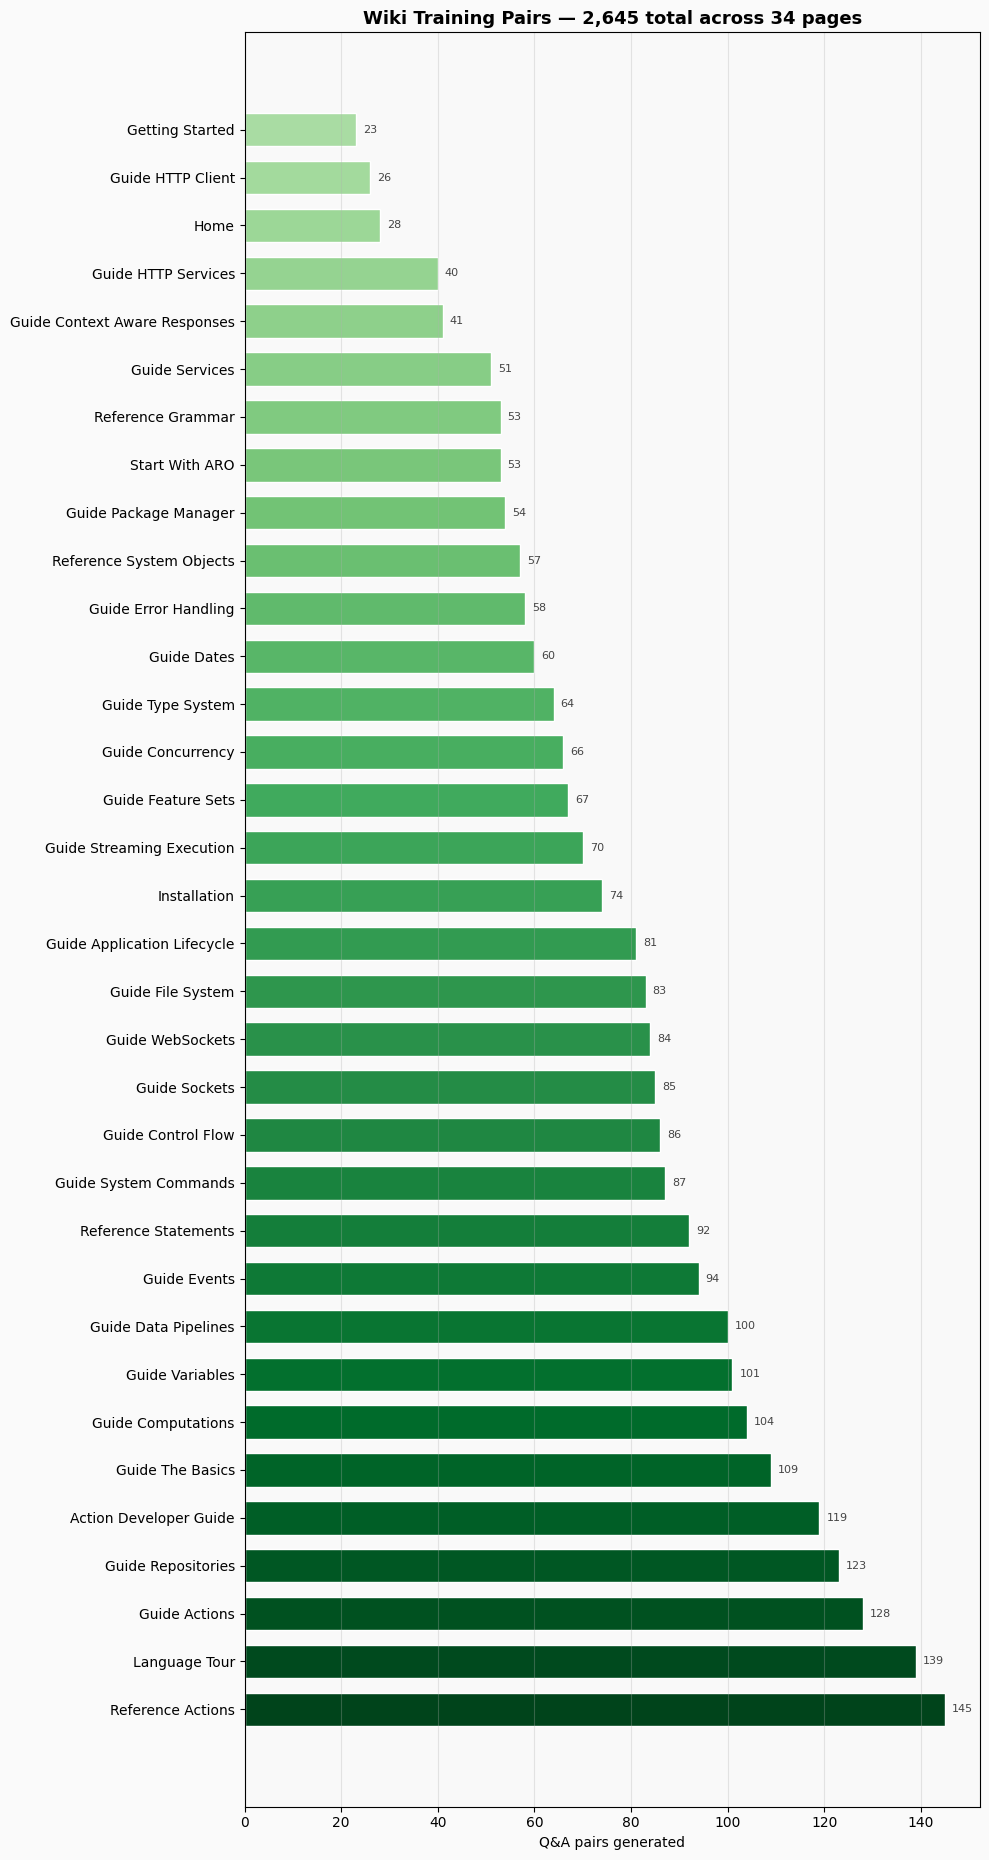

Saved: run/2026-03-27/07b_wiki_training.png


In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '07b_wiki_training.png'

_page_counts = {}
for p in all_pairs_loaded:
    page = p.get('source', '').replace('wiki:', '') if 'wiki:' in p.get('source', '') else p.get('source', '')
    _page_counts[page] = _page_counts.get(page, 0) + 1

_sorted = sorted(_page_counts.items(), key=lambda x: x[1])
_labels = [p.replace('-', ' ') for p, _ in _sorted]
_values = [n for _, n in _sorted]
_colors = plt.cm.Greens([0.35 + 0.65 * i / max(1, len(_values) - 1) for i in range(len(_values))])

fig, ax = plt.subplots(figsize=(10, max(4, len(_labels) * 0.55)))
bars = ax.barh(_labels, _values, color=_colors, edgecolor='white', height=0.7)
ax.set_xlabel('Q&A pairs generated')
ax.set_title(
    f'Wiki Training Pairs — {len(all_pairs_loaded):,} total across {len(_page_counts)} pages',
    fontsize=13, fontweight='bold'
)
for bar, n in zip(bars, _values):
    ax.text(n + max(_values) * 0.01, bar.get_y() + bar.get_height() / 2,
            str(n), va='center', fontsize=8, color='#444')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {_out}')


In [10]:
# ── Samples per wiki page ─────────────────────────────────────────────────────
import json, random
from collections import defaultdict

_pairs = []
if OWN_FILE.exists():
    with open(OWN_FILE) as f:
        for line in f:
            if line.strip():
                _pairs.append(json.loads(line))

_by_page = defaultdict(list)
for p in _pairs:
    page = p.get('source', '').replace('wiki:', '') if 'wiki:' in p.get('source', '') else p.get('source', '')
    _by_page[page].append(p)

SAMPLES_PER_PAGE = 2

# Show a few pages as a representative cross-section
_show_pages = sorted(_by_page, key=lambda pg: -len(_by_page[pg]))[:8]

for page in _show_pages:
    pool = _by_page[page]
    print(f'\n{"─"*72}')
    print(f'  {page.replace("-", " ")}  ({len(pool)} pairs)')
    print('─'*72)
    for s in random.sample(pool, min(SAMPLES_PER_PAGE, len(pool))):
        print(f'Q: {s["instruction"][:220]}')
        out = s.get('output', '')
        print(f'A: {out[:320]}{"..." if len(out) > 320 else ""}')
        print()


────────────────────────────────────────────────────────────────────────
  Reference Actions  (145 pairs)
────────────────────────────────────────────────────────────────────────
Q: How do I compute the length of a string?
A: Use the `length` operation with the `from` preposition. For example:
```aro
Compute the <len: length> from the <greeting>.`

Q: Can I log the value of a variable?
A: This works for any valid expression that evaluates to a value.


────────────────────────────────────────────────────────────────────────
  Language Tour  (139 pairs)
────────────────────────────────────────────────────────────────────────
Q: How do I extract a field from an event in ARO?
A: Use the `Extract the <field> from the <event: field>` syntax. For example: `Extract the <task> from the <event: task>` extracts the entire task object. To get a nested field: `Extract the <title> from the <task: title>`. You can also extract directly into variables.

Q: How would I add a DELETE endpoint to the Ta

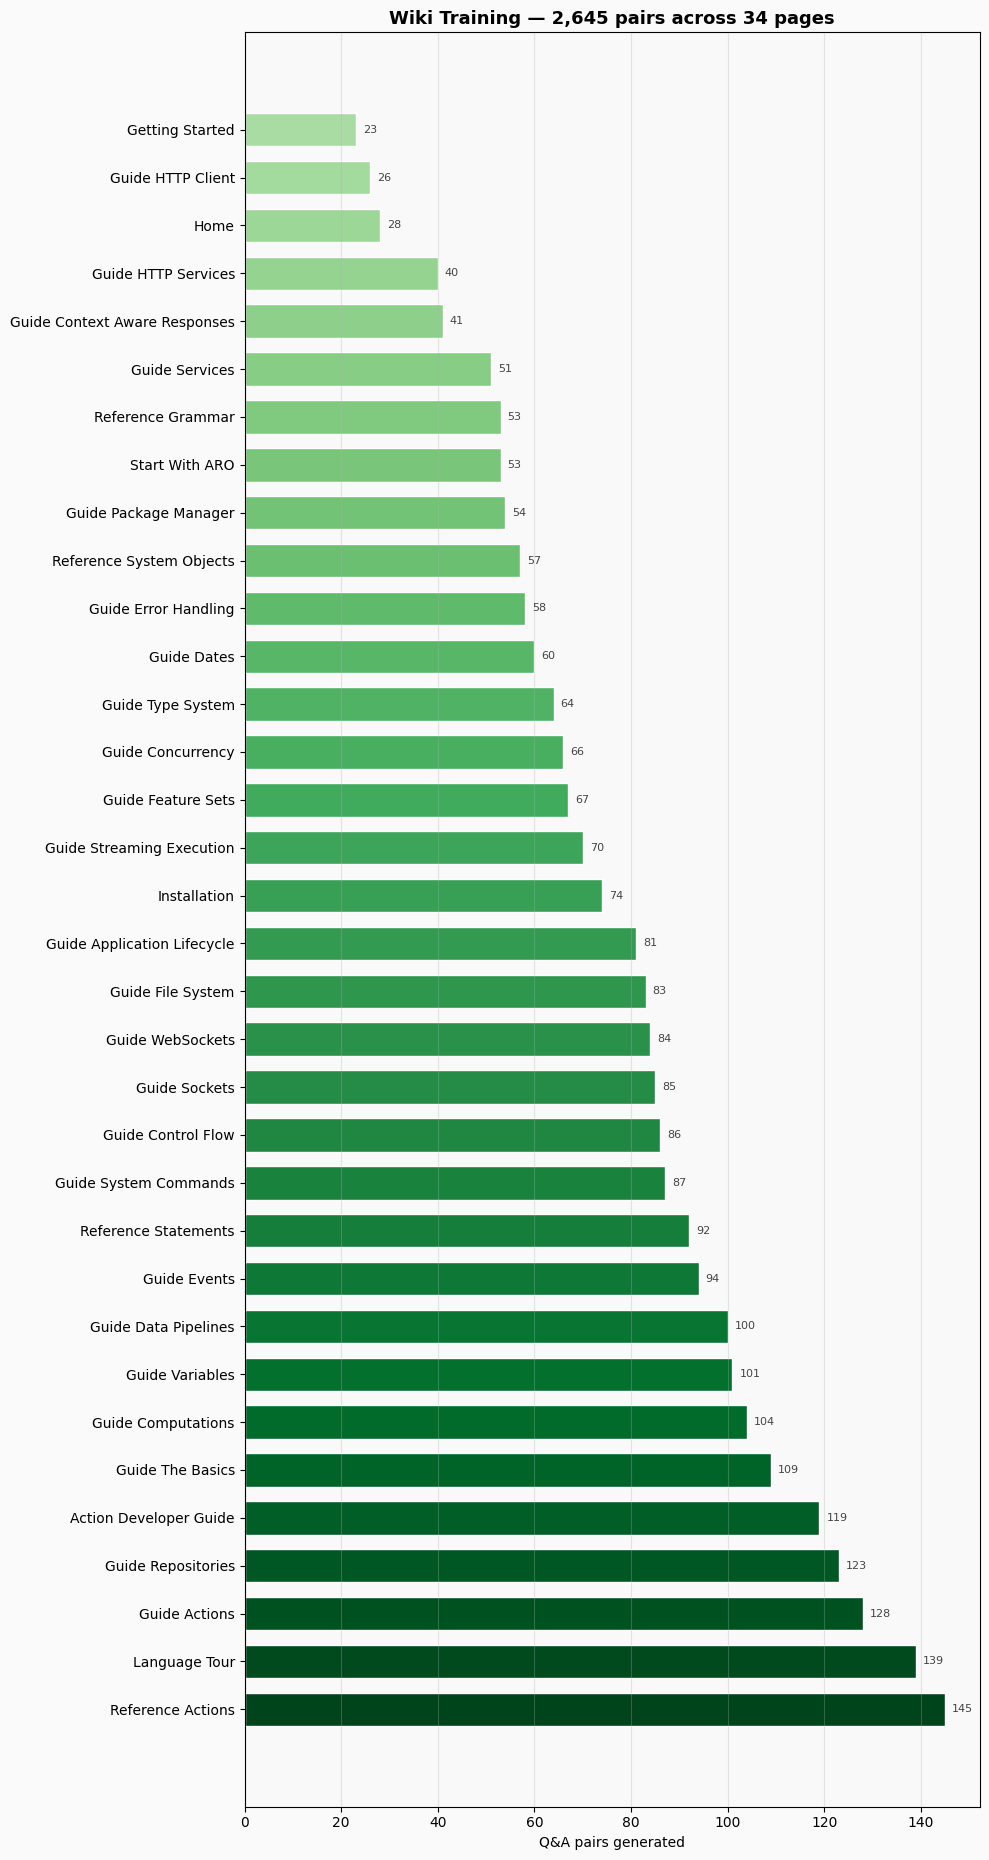

Saved: run/2026-03-27/08_wiki_training.png


In [11]:
# ── Final status: wiki training pairs per page ────────────────────────────────
import json, matplotlib.pyplot as plt
from pathlib import Path
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '08_wiki_training.png'

_page_counts = {}
with open(OWN_FILE) as _f:
    for _line in _f:
        if _line.strip():
            _p = json.loads(_line)
            _page = _p.get('source', '').replace('wiki:', '') if 'wiki:' in _p.get('source', '') else _p.get('source', '')
            _page_counts[_page] = _page_counts.get(_page, 0) + 1

_sorted = sorted(_page_counts.items(), key=lambda x: x[1])
_labels = [p.replace('-', ' ') for p, _ in _sorted]
_values = [n for _, n in _sorted]
_colors = plt.cm.Greens([0.35 + 0.65 * i / max(1, len(_values) - 1) for i in range(len(_values))])

fig, ax = plt.subplots(figsize=(10, max(4, len(_labels) * 0.55)))
bars = ax.barh(_labels, _values, color=_colors, edgecolor='white', height=0.7)
ax.set_xlabel('Q&A pairs generated')
ax.set_title(
    f'Wiki Training — {sum(_values):,} pairs across {len(_page_counts)} pages',
    fontsize=13, fontweight='bold'
)
for bar, n in zip(bars, _values):
    ax.text(n + max(_values) * 0.01, bar.get_y() + bar.get_height() / 2,
            str(n), va='center', fontsize=8, color='#444')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('#fafafa')
fig.tight_layout()
fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {_out}')
